# 03: MLP

Two MLP experiments on metaorder training data.

**MLP-A; controlled inputs (same as power law OLS):**
- Inputs: log_Q, log_sigma, log_V
- Same information as the OLS benchmarks, different functional form
- Tests whether a nonlinear model improves on linear OLS given the same features

**MLP-B; richer inputs:**
- Inputs: log_Q, log_sigma, log_V, log_n_child, utc_hour_sin, utc_hour_cos
- Adds metaorder length and time-of-day encoding
- Tests whether additional features help beyond functional form

Both trained on mo_train.parquet, evaluated on mo_test.parquet.
OOS MSE targets from 02_benchmark.ipynb: constrained 39.28, fitted 42.44, Almgren-Chriss 25.29.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

DATA_DIR    = Path("../data/processed")
OUTPUT_DIR  = Path("../outputs")
MODEL_DIR   = OUTPUT_DIR / "models"
FIGURES_DIR = OUTPUT_DIR / "figures"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

torch.manual_seed(42)
np.random.seed(42)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

Device: cpu


## Load and prepare

In [22]:
train = pd.read_parquet(DATA_DIR / "mo_train.parquet")
test  = pd.read_parquet(DATA_DIR / "mo_test.parquet")

def prepare(df: pd.DataFrame) -> pd.DataFrame:
    df = df[(df["I"] > 0) & (df["Q_norm"] > 0) & (df["sigma_daily"] > 0)].copy()
    df["log_I"]       = np.log(df["I"])
    df["log_Q"]       = np.log(df["Q_norm"])
    df["log_sigma"]   = np.log(df["sigma_daily"])
    df["log_V"]       = np.log(df["V_daily"])
    df["log_n_child"] = np.log(df["n_child"])
    # UTC hour from start timestamp
    hour = pd.to_datetime(df["start_ts"], unit="ms").dt.hour
    df["utc_hour_sin"] = np.sin(2 * np.pi * hour / 24)
    df["utc_hour_cos"] = np.cos(2 * np.pi * hour / 24)
    mu, sd = df["log_I"].mean(), df["log_I"].std()
    df = df[np.abs(df["log_I"] - mu) < 3 * sd].reset_index(drop=True)
    return df

train_p = prepare(train)
test_p  = prepare(test)

print(f"Train: {len(train_p):,}")
print(f"Test : {len(test_p):,}")

Train: 1,121,876
Test : 279,783


## Model definition

In [23]:
class ImpactMLP(nn.Module):
    def __init__(self, input_dim: int, hidden: int = 64, layers: int = 3, dropout: float = 0.3):
        super().__init__()
        net = [nn.Linear(input_dim, hidden), nn.ReLU(), nn.Dropout(dropout)]
        for _ in range(layers - 1):
            net += [nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout)]
        net += [nn.Linear(hidden, 1)]
        self.net = nn.Sequential(*net)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)

## Training function

In [24]:
def train_mlp(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    input_dim: int,
    hidden: int = 64,
    layers: int = 3,
    epochs: int = 100,
    batch_size: int = 512,
    lr: float = 1e-3,
    patience: int = 10,
) -> tuple[ImpactMLP, list, list]:

    model = ImpactMLP(input_dim, hidden, layers).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.MSELoss()

    X_tr = torch.tensor(X_train, dtype=torch.float32)
    y_tr = torch.tensor(y_train, dtype=torch.float32)
    X_vl = torch.tensor(X_val,   dtype=torch.float32).to(DEVICE)
    y_vl = torch.tensor(y_val,   dtype=torch.float32).to(DEVICE)

    loader = DataLoader(
        TensorDataset(X_tr, y_tr),
        batch_size=batch_size,
        shuffle=True,
    )

    train_losses, val_losses = [], []
    best_val_loss = float("inf")
    best_state    = None
    patience_ctr  = 0

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for Xb, yb in loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(Xb)
        scheduler.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_vl), y_vl).item()

        train_losses.append(epoch_loss / len(X_train))
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr  = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"  Early stopping at epoch {epoch + 1}")
                break

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d}  train={train_losses[-1]:.4f}  val={val_loss:.4f}")

    model.load_state_dict(best_state)
    return model, train_losses, val_losses

## MLP-A: controlled inputs

In [25]:
FEATURES_A = ["log_Q", "log_sigma", "log_V"]

# 90/10 train/val split within training data
val_cut = int(len(train_p) * 0.9)
tr_a    = train_p.iloc[:val_cut]
vl_a    = train_p.iloc[val_cut:]

scaler_a = StandardScaler().fit(tr_a[FEATURES_A].values)

X_tr_a = scaler_a.transform(tr_a[FEATURES_A].values)
y_tr_a = tr_a["log_I"].values
X_vl_a = scaler_a.transform(vl_a[FEATURES_A].values)
y_vl_a = vl_a["log_I"].values
X_te_a = scaler_a.transform(test_p[FEATURES_A].values)
y_te   = test_p["log_I"].values

joblib.dump(scaler_a, MODEL_DIR / "scaler_a.pkl")

print("Training MLP-A...")
mlp_a, train_loss_a, val_loss_a = train_mlp(
    X_tr_a, y_tr_a, X_vl_a, y_vl_a,
    input_dim=len(FEATURES_A),
)
torch.save(mlp_a.state_dict(), MODEL_DIR / "mlp_a.pt")
print("Saved mlp_a.pt")

Training MLP-A...
  Epoch  10  train=0.6362  val=0.6411
  Early stopping at epoch 19
Saved mlp_a.pt


## MLP-B: richer inputs

In [26]:
FEATURES_B = ["log_Q", "log_sigma", "log_V", "log_n_child", "utc_hour_sin", "utc_hour_cos"]

tr_b = train_p.iloc[:val_cut]
vl_b = train_p.iloc[val_cut:]

scaler_b = StandardScaler().fit(tr_b[FEATURES_B].values)

X_tr_b = scaler_b.transform(tr_b[FEATURES_B].values)
y_tr_b = tr_b["log_I"].values
X_vl_b = scaler_b.transform(vl_b[FEATURES_B].values)
y_vl_b = vl_b["log_I"].values
X_te_b = scaler_b.transform(test_p[FEATURES_B].values)

joblib.dump(scaler_b, MODEL_DIR / "scaler_b.pkl")

print("Training MLP-B...")
mlp_b, train_loss_b, val_loss_b = train_mlp(
    X_tr_b, y_tr_b, X_vl_b, y_vl_b,
    input_dim=len(FEATURES_B),
)
torch.save(mlp_b.state_dict(), MODEL_DIR / "mlp_b.pt")
print("Saved mlp_b.pt")

Training MLP-B...
  Epoch  10  train=0.5562  val=0.5761
  Epoch  20  train=0.5544  val=0.5719
  Epoch  30  train=0.5533  val=0.5754
  Early stopping at epoch 31
Saved mlp_b.pt


## Training curves

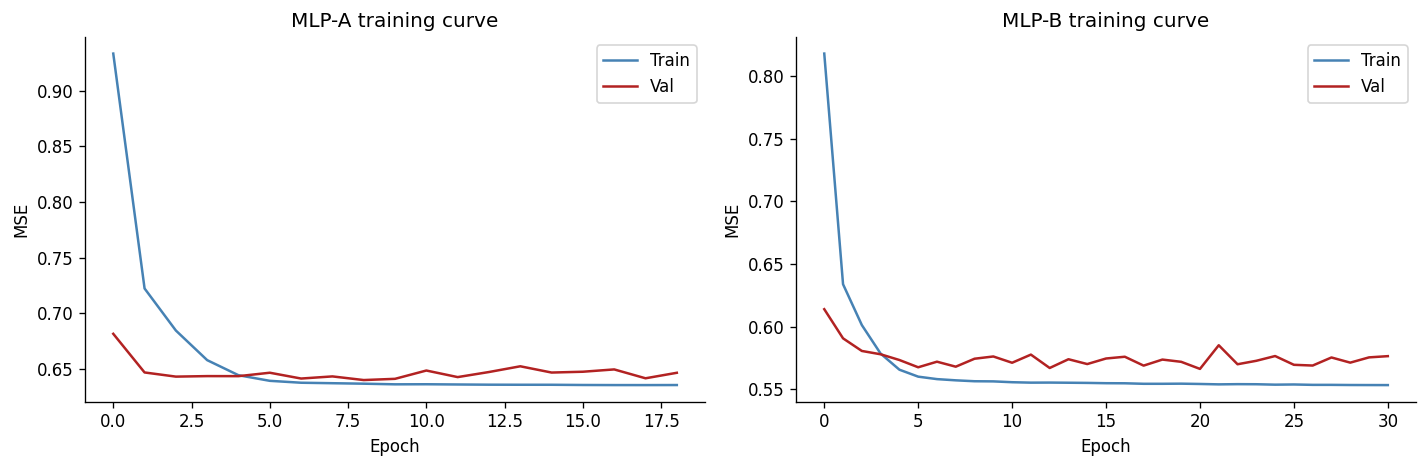

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_loss_a, label="Train", color="steelblue")
axes[0].plot(val_loss_a,   label="Val",   color="firebrick")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].set_title("MLP-A training curve")
axes[0].legend()

axes[1].plot(train_loss_b, label="Train", color="steelblue")
axes[1].plot(val_loss_b,   label="Val",   color="firebrick")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE")
axes[1].set_title("MLP-B training curve")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "mlp_training_curves.png", bbox_inches="tight")
plt.show()

## Out-of-sample evaluation

In [28]:
def predict(model: ImpactMLP, X: np.ndarray) -> np.ndarray:
    model.eval()
    with torch.no_grad():
        t = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        return model(t).cpu().numpy()

def evaluate(name: str, y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    mse  = mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    bias = (y_pred - y_true).mean()
    print(f"  {name:<30} MSE={mse:.4f}  MAE={mae:.4f}  R2={r2:.4f}  Bias={bias:.4f}")
    return {"model": name, "mse": mse, "mae": mae, "r2": r2, "bias": bias}

pred_a = predict(mlp_a, X_te_a)
pred_b = predict(mlp_b, X_te_b)

print("Out-of-sample results:")
mlp_results = [
    evaluate("MLP-A (log_Q, log_sigma, log_V)", y_te, pred_a),
    evaluate("MLP-B (+ n_child, utc_hour)",     y_te, pred_b),
]

mlp_df = pd.DataFrame(mlp_results)
mlp_df.to_csv(OUTPUT_DIR / "mlp_results.csv", index=False)

Out-of-sample results:
  MLP-A (log_Q, log_sigma, log_V) MSE=0.6848  MAE=0.6169  R2=0.3241  Bias=0.0912
  MLP-B (+ n_child, utc_hour)    MSE=0.6042  MAE=0.5826  R2=0.4037  Bias=0.0436


## Residuals vs Q_norm

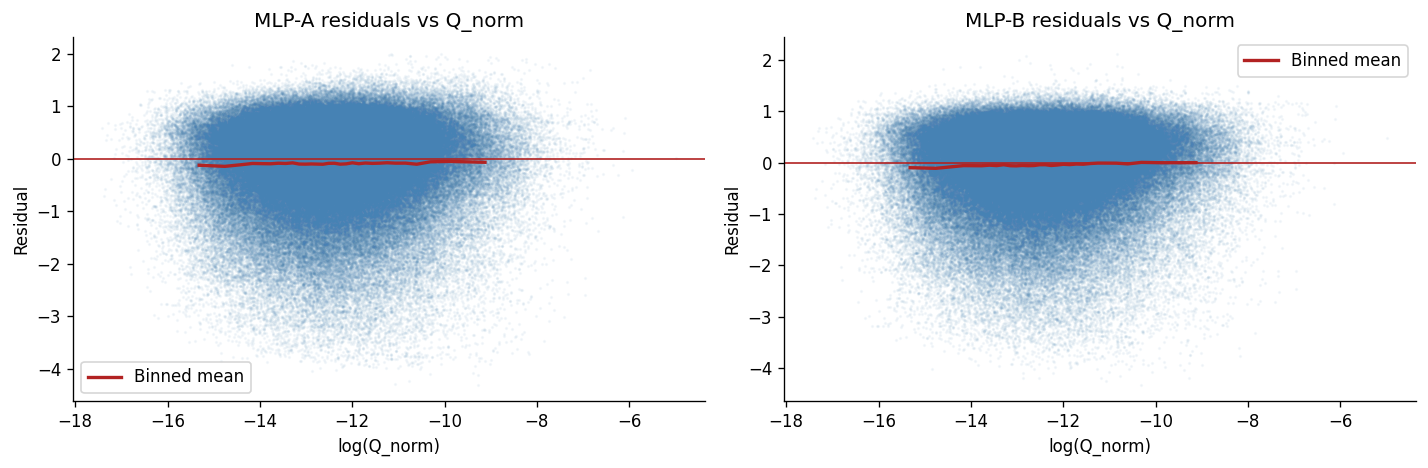

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, pred, name in [
    (axes[0], pred_a, "MLP-A"),
    (axes[1], pred_b, "MLP-B"),
]:
    resid = y_te - pred
    ax.scatter(test_p["log_Q"].values, resid, s=1, alpha=0.05, color="steelblue")
    ax.axhline(0, color="firebrick", linewidth=1)

    tmp = test_p[["log_Q"]].copy()
    tmp["resid"] = resid
    tmp["q_bin"] = pd.qcut(tmp["log_Q"], q=30, duplicates="drop")
    bm = tmp.groupby("q_bin", observed=True)["resid"].mean()
    bc = tmp.groupby("q_bin", observed=True)["log_Q"].median()
    ax.plot(bc.values, bm.values, color="firebrick", linewidth=2,
            label="Binned mean")

    ax.set_xlabel("log(Q_norm)")
    ax.set_ylabel("Residual")
    ax.set_title(f"{name} residuals vs Q_norm")
    ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "mlp_residuals_vs_q.png", bbox_inches="tight")
plt.show()

## Summary

In [31]:
benchmarks_df = pd.read_csv("../outputs/benchmark_results.csv")

print("=" * 55)
print("OOS MSE comparison")
print("=" * 55)
for _, row in benchmarks_df.iterrows():
    print(f"  {row['model']:<35} {row['mse']:.4f}  (benchmark)")
for row in mlp_results:
    print(f"  {row['model']:<35} {row['mse']:.4f}")
print("=" * 55)
print("Next: 04_interpretability.ipynb")

OOS MSE comparison
  Power law (delta=0.5, constrained)  1.2816  (benchmark)
  Power law (delta fitted)            1.0630  (benchmark)
  Almgren-Chriss                      0.6718  (benchmark)
  MLP-A (log_Q, log_sigma, log_V)     0.6848
  MLP-B (+ n_child, utc_hour)         0.6042
Next: 04_interpretability.ipynb
